In [1]:
# Exploring the geom_drugs_boltz Dataset
# This notebook demonstrates how to load and explore molecules from the dataset

import numpy as np
import json
from pathlib import Path
from typing import Tuple
import matplotlib.pyplot as plt
from collections import Counter

# Set the dataset path
DATASET_DIR = Path("/datastor1/dy4652/proteinzen/geom_drugs_boltz")
MANIFEST_PATH = DATASET_DIR / "manifest.json"
STRUCTURES_DIR = DATASET_DIR / "structures"

print(f"Dataset directory: {DATASET_DIR}")
print(f"Manifest exists: {MANIFEST_PATH.exists()}")
print(f"Structures directory exists: {STRUCTURES_DIR.exists()}")


Dataset directory: /datastor1/dy4652/proteinzen/geom_drugs_boltz
Manifest exists: True
Structures directory exists: True


In [2]:
# Load the manifest to see all available molecules
with open(MANIFEST_PATH, 'r') as f:
    manifest = json.load(f)

print(f"Total number of molecules in dataset: {len(manifest)}")
print(f"\nFirst molecule entry:")
print(json.dumps(manifest[0], indent=2))


Total number of molecules in dataset: 304347

First molecule entry:
{
  "id": "5a62f7db366df96e250cbf9e33755651c5114ddda7b2c587f5520605d206b2de",
  "structure": {
    "resolution": null,
    "method": "QM9:C[C@@H](O[C@H]1OCCN(Cc2nn(P(=O)(O)O)c(=O)[nH]2)[C@H]1c1ccc(F)cc1)c1cc(C(F)(F)F)cc(C(F)(F)F)c1",
    "deposited": null,
    "released": null,
    "revised": null,
    "num_chains": 1,
    "num_interfaces": 0,
    "pH": null,
    "temperature": null
  },
  "chains": [
    {
      "chain_id": 0,
      "chain_name": "A",
      "mol_type": 0,
      "cluster_id": -1,
      "msa_id": "",
      "num_residues": 1,
      "valid": true,
      "entity_id": null
    }
  ],
  "interfaces": [],
  "inference_options": null,
  "templates": null,
  "md": null,
  "affinity": null
}


In [3]:
# Helper functions to load molecule data
def load_molecule_data(npz_path: Path) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Load molecular data from a .npz file.
    
    Returns:
        coordinates: (N, 3) array of atom coordinates
        atom_elements: (N,) array of atomic numbers
        bond_matrix: (N, N) binary adjacency matrix
    """
    data = np.load(npz_path)
    atoms = data['atoms']
    bonds = data['bonds']
    
    coordinates = atoms['coords']
    atom_elements = atoms['element']
    
    num_atoms = len(atoms)
    bond_matrix = np.zeros((num_atoms, num_atoms), dtype=np.int32)
    
    for bond in bonds:
        atom_1 = bond['atom_1']
        atom_2 = bond['atom_2']
        bond_matrix[atom_1, atom_2] = 1
        bond_matrix[atom_2, atom_1] = 1
    
    return coordinates, atom_elements, bond_matrix

def get_atom_symbols(atomic_numbers: np.ndarray) -> list:
    """Convert atomic numbers to element symbols."""
    element_map = {
        1: 'H', 2: 'He', 3: 'Li', 4: 'Be', 5: 'B', 6: 'C', 7: 'N', 8: 'O',
        9: 'F', 10: 'Ne', 11: 'Na', 12: 'Mg', 13: 'Al', 14: 'Si', 15: 'P',
        16: 'S', 17: 'Cl', 18: 'Ar', 19: 'K', 20: 'Ca', 35: 'Br', 53: 'I'
    }
    return [element_map.get(int(num), f'X{int(num)}') for num in atomic_numbers]

def get_structure_path(mol_id: str) -> Path:
    """Get the path to a molecule's structure file based on its ID."""
    # Structure files are organized in subdirectories based on characters at index 1-2
    # (This matches the processing script which uses data_id[1:3])
    subdir = mol_id[1:3]
    return STRUCTURES_DIR / subdir / f"{mol_id}.npz"

print("Helper functions loaded!")


Helper functions loaded!


In [4]:
# Explore dataset statistics
print("Dataset Statistics:")
print("=" * 60)

# Get structure paths for all molecules
structure_paths = []
for entry in manifest:
    mol_id = entry.get('id', '')
    if mol_id:
        struct_path = get_structure_path(mol_id)
        if struct_path.exists():
            structure_paths.append(struct_path)

print(f"Found {len(structure_paths)} structure files")

# Sample a few molecules to get statistics
sample_size = min(100, len(structure_paths))
if len(structure_paths) > 0:
    indices = np.random.choice(len(structure_paths), size=sample_size, replace=False)
    sample_paths = [structure_paths[i] for i in indices]
else:
    sample_paths = []

atom_counts = []
element_counts = Counter()

for path in sample_paths:
    try:
        coords, elements, bond_matrix = load_molecule_data(path)
        atom_counts.append(len(coords))
        element_counts.update(elements.astype(int))
    except Exception as e:
        print(f"Error loading {path}: {e}")

if atom_counts:
    print(f"\nAtom count statistics (from {len(atom_counts)} samples):")
    print(f"  Min: {min(atom_counts)}")
    print(f"  Max: {max(atom_counts)}")
    print(f"  Mean: {np.mean(atom_counts):.1f}")
    print(f"  Median: {np.median(atom_counts):.1f}")
    
    print(f"\nMost common elements (from samples):")
    for element_num, count in element_counts.most_common(10):
        symbol = get_atom_symbols(np.array([element_num]))[0]
        print(f"  {symbol} (Z={element_num}): {count} atoms")


Dataset Statistics:
Found 304347 structure files

Atom count statistics (from 100 samples):
  Min: 14
  Max: 37
  Mean: 24.5
  Median: 24.0

Most common elements (from samples):
  C (Z=6): 1768 atoms
  N (Z=7): 300 atoms
  O (Z=8): 285 atoms
  S (Z=16): 54 atoms
  F (Z=9): 23 atoms
  Cl (Z=17): 17 atoms
  Br (Z=35): 6 atoms
  H (Z=1): 1 atoms


In [5]:
# Load and examine a specific molecule
# You can change this to any molecule ID from the manifest
mol_id = manifest[0]['id']  # Get first molecule ID
print(f"Loading molecule: {mol_id}")

struct_path = get_structure_path(mol_id)
if struct_path.exists():
    coords, elements, bond_matrix = load_molecule_data(struct_path)
    atom_symbols = get_atom_symbols(elements)
    
    print(f"\nMolecule Information:")
    print(f"  Number of atoms: {len(coords)}")
    print(f"  Number of bonds: {bond_matrix.sum() // 2}")
    print(f"  Elements present: {set(atom_symbols)}")
    print(f"  Element counts: {Counter(atom_symbols)}")
    
    print(f"\nCoordinates shape: {coords.shape}")
    print(f"Coordinate range:")
    print(f"  X: [{coords[:, 0].min():.2f}, {coords[:, 0].max():.2f}]")
    print(f"  Y: [{coords[:, 1].min():.2f}, {coords[:, 1].max():.2f}]")
    print(f"  Z: [{coords[:, 2].min():.2f}, {coords[:, 2].max():.2f}]")
    
    print(f"\nFirst 10 atoms:")
    for i in range(min(10, len(coords))):
        print(f"  {i}: {atom_symbols[i]:>2} at ({coords[i, 0]:7.3f}, {coords[i, 1]:7.3f}, {coords[i, 2]:7.3f})")
else:
    print(f"Structure file not found: {struct_path}")


Loading molecule: 5a62f7db366df96e250cbf9e33755651c5114ddda7b2c587f5520605d206b2de

Molecule Information:
  Number of atoms: 41
  Number of bonds: 44
  Elements present: {'C', 'P', 'N', 'O', 'F'}
  Element counts: Counter({'C': 23, 'F': 7, 'O': 6, 'N': 4, 'P': 1})

Coordinates shape: (41, 3)
Coordinate range:
  X: [-7.87, 5.30]
  Y: [-4.24, 4.19]
  Z: [-3.27, 2.59]

First 10 atoms:
  0:  C at ( -0.910,  -1.934,  -3.265)
  1:  C at ( -0.559,  -0.841,  -2.258)
  2:  C at (  0.650,  -1.247,  -1.444)
  3:  C at (  0.471,  -1.975,  -0.277)
  4:  C at (  1.564,  -2.342,   0.496)
  5:  C at (  2.850,  -1.997,   0.117)
  6:  C at (  3.018,  -1.281,  -1.060)
  7:  C at (  1.935,  -0.902,  -1.839)
  8:  C at (  4.409,  -0.858,  -1.439)
  9:  F at (  5.305,  -1.848,  -1.279)


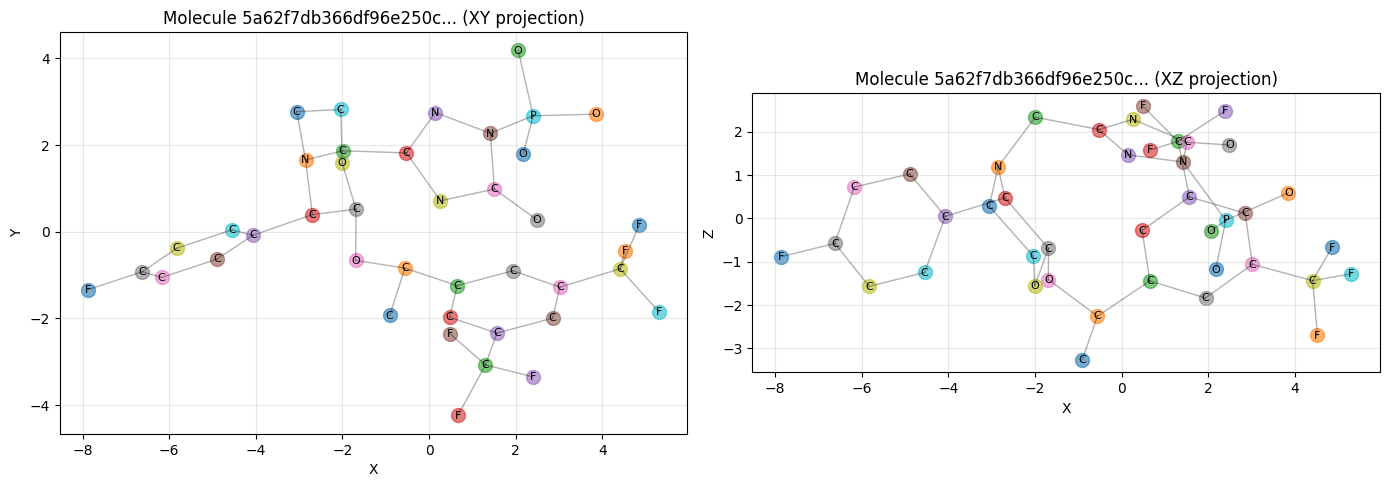

Visualized molecule: 5a62f7db366df96e250cbf9e33755651c5114ddda7b2c587f5520605d206b2de
Total atoms: 41


In [6]:
# Visualize molecule structure (2D projection)
# This creates a simple 2D visualization of the molecule

mol_id = manifest[0]['id']  # Change this to explore different molecules
struct_path = get_structure_path(mol_id)

if struct_path.exists():
    coords, elements, bond_matrix = load_molecule_data(struct_path)
    atom_symbols = get_atom_symbols(elements)
    
    # Create 2D projection (XY plane)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: XY projection
    ax = axes[0]
    for i in range(len(coords)):
        ax.scatter(coords[i, 0], coords[i, 1], s=100, alpha=0.6)
        ax.text(coords[i, 0], coords[i, 1], atom_symbols[i], fontsize=8, ha='center', va='center')
    
    # Draw bonds
    for i in range(len(bond_matrix)):
        for j in range(i+1, len(bond_matrix)):
            if bond_matrix[i, j] > 0:
                ax.plot([coords[i, 0], coords[j, 0]], 
                       [coords[i, 1], coords[j, 1]], 
                       'k-', alpha=0.3, linewidth=1)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Molecule {mol_id[:20]}... (XY projection)')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # Plot 2: XZ projection
    ax = axes[1]
    for i in range(len(coords)):
        ax.scatter(coords[i, 0], coords[i, 2], s=100, alpha=0.6)
        ax.text(coords[i, 0], coords[i, 2], atom_symbols[i], fontsize=8, ha='center', va='center')
    
    # Draw bonds
    for i in range(len(bond_matrix)):
        for j in range(i+1, len(bond_matrix)):
            if bond_matrix[i, j] > 0:
                ax.plot([coords[i, 0], coords[j, 0]], 
                       [coords[i, 2], coords[j, 2]], 
                       'k-', alpha=0.3, linewidth=1)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_title(f'Molecule {mol_id[:20]}... (XZ projection)')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Visualized molecule: {mol_id}")
    print(f"Total atoms: {len(coords)}")
else:
    print(f"Structure file not found: {struct_path}")


## Summary

This notebook provides tools to explore the `geom_drugs_boltz` dataset:

1. **Load manifest**: See all available molecules
2. **Load molecules**: Load individual molecules from `.npz` files
3. **Browse molecules**: Explore molecules by index
4. **Visualize**: Create 2D projections of molecular structures
5. **Search**: Find molecules by element composition

### Quick Tips:

- Change `mol_id` or use `browse_molecule(index)` to explore different molecules
- Use `find_molecules_with_elements(['C', 'N'])` to search for specific compositions
- The dataset contains molecular structures stored as:
  - Atom coordinates (3D positions)
  - Atom elements (atomic numbers)
  - Bond connectivity (adjacency matrix)

### Next Steps:

- Try visualizing different molecules
- Analyze bond patterns
- Explore molecular properties
- Compare different conformers


## About Conformations in geom_drugs_boltz

**Important Finding:**

The `geom_drugs_boltz` dataset contains **ONE conformer per molecule**, not multiple conformations.

### How it works:

1. **Original GEOM dataset**: The source data (before processing) contains multiple conformers per molecule stored in pickle files with a `conformers` array.

2. **Processing**: When creating `geom_drugs_boltz`, the processing script (`scripts/data/geom.py`) explicitly takes **only the first conformer**:
   ```python
   conformer_data = data_dict['conformers']
   # we just take the first conformer for now
   rd_mol = conformer_data[0]['rd_mol']
   ```

3. **Stored data**: Each molecule ID in the manifest maps to a single `.npz` file containing one 3D structure (one conformer).

4. **Manifest.json**: Does NOT contain conformation information. Each entry represents one molecule with one conformer.

### Summary:
- ✅ Each molecule has a unique ID (hash of SMILES)
- ✅ Each ID maps to exactly one `.npz` structure file
- ✅ Each structure file contains one conformer
- ❌ The manifest does NOT track multiple conformations
- ❌ Multiple conformers from the original dataset are not preserved in this processed version


In [9]:
# Verify: Check if any SMILES appear multiple times (indicating multiple conformers)
# In the processed dataset, each SMILES should map to exactly one ID

import json
from collections import defaultdict

# Load manifest
with open(MANIFEST_PATH, 'r') as f:
    manifest = json.load(f)

# Group by SMILES
smiles_to_ids = defaultdict(list)
for entry in manifest:
    method = entry.get('structure', {}).get('method', '')
    if method.startswith('QM9:'):
        smiles = method[4:]  # Remove 'QM9:' prefix
        mol_id = entry.get('id', '')
        smiles_to_ids[smiles].append(mol_id)

# Check for duplicates
duplicates = {smiles: ids for smiles, ids in smiles_to_ids.items() if len(ids) > 1}

print(f"Total unique SMILES: {len(smiles_to_ids)}")
print(f"SMILES with multiple IDs: {len(duplicates)}")

if duplicates:
    print(f"\n⚠️ Found {len(duplicates)} SMILES with multiple entries!")
    print("\nFirst few examples:")
    for smiles, ids in list(duplicates.items())[:3]:
        print(f"\nSMILES: {smiles[:80]}...")
        print(f"  IDs ({len(ids)}):")
        for i, mol_id in enumerate(ids[:3]):
            print(f"    {i+1}. {mol_id[:40]}...")
        if len(ids) > 3:
            print(f"    ... and {len(ids)-3} more")
else:
    print("\n✓ Each SMILES maps to exactly one molecule ID")
    print("  (This confirms one conformer per molecule in the processed dataset)")


Total unique SMILES: 304338
SMILES with multiple IDs: 8

⚠️ Found 8 SMILES with multiple entries!

First few examples:

SMILES: C[C@@H]1NC(=O)[C@@H](N)CNC(=O)[C@H](C2CCNC(N)=N2)NC(=O)C(=CNC(N)=O)NC(=O)[C@H](C...
  IDs (2):
    1. 2d7a62673e9145121168ae5b04abad6464ae3b03...
    2. 639ad5f1076c69a30771a40f0052e47f81d13e18...

SMILES: Cl[C@H]1[C@H](Cl)[C@@H](Cl)[C@@H](Cl)[C@H](Cl)[C@H]1Cl...
  IDs (2):
    1. 823d45f59ea716552662f5acc2b7a39fac2dda42...
    2. 741b7480878349491dbf1b9c87d0011950bd74f5...

SMILES: COCCCOc1ccnc(CS(=O)c2nc3ccccc3[nH]2)c1C...
  IDs (2):
    1. 7281971d9d8069df4272a2a5d76d21d0d562b280...
    2. 1891669dbcc68d6559784a7206edbb84968bd158...


## Complete Dataset Structure Overview

### Directory Organization

```
geom_drugs_boltz/
├── manifest.json          # Index of all molecules (304,347 entries)
├── structures/            # 3D structure files (.npz format)
│   ├── 00/               # Organized by 2-char subdirectory (chars 1-2 of ID)
│   ├── 01/
│   ├── ...
│   └── ff/
└── records/              # Individual record JSON files (mirrors manifest)
    ├── 00/
    ├── 01/
    └── ...
```

### File Naming Convention

- **Molecule ID**: SHA256 hash of the SMILES string (64 hex characters)
- **Subdirectory**: Uses characters at **index 1-2** of the ID (not 0-1!)
  - Example: ID `5a62f7db...` → subdirectory `a6`
- **Structure file**: `{molecule_id}.npz`
- **Record file**: `{molecule_id}.json`

### .npz File Structure

Each `.npz` file contains a single conformer with:

```python
{
    'atoms': structured array with fields:
        - name: atom name (4 bytes)
        - element: atomic number (int8)
        - charge: formal charge (int8)
        - coords: 3D coordinates (float32[3])
        - conformer: reference conformer coords (float32[3]) - same as coords
        - is_present: boolean flag
        - chirality: chirality indicator (int8)
    
    'bonds': structured array with:
        - atom_1: index of first atom (int32)
        - atom_2: index of second atom (int32)
        - type: bond type (int8): 1=single, 2=double, 3=triple, 4=aromatic
    
    'residues': residue information
    'chains': chain information
    'connections': inter-chain connections
    'interfaces': interface information
    'mask': presence mask
}
```

### Manifest.json Structure

Each entry contains:
- `id`: Unique molecule identifier (SHA256 hash of SMILES)
- `structure`: Metadata including SMILES in `method` field (format: `"QM9:{smiles}"`)
- `chains`: Chain information (usually 1 chain per molecule)
- `interfaces`: Empty for small molecules
- Other metadata fields (mostly null for this dataset)
